# CT-Scan

## Load Library

In [ ]:
%%capture
!pip install -Uq gdown
!pip install split-folders
!pip install natsort
!pip install torch transformers datasets evaluate pillow==9.2.0

!pip uninstall timm --y
!pip -q install --pre timm

## Library

In [ ]:
import os
import numpy as np
import pandas as pd
import splitfolders
from glob import glob
# from tqdm import tqdm, trange
from tqdm.autonotebook import tqdm, trange
from numba import njit, jit
from natsort import natsorted

import matplotlib.pyplot as plt

#PIL
from PIL import Image, ImageOps

#random
from random import sample

#open cv
import cv2

#sklearn
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, train_test_split, KFold

#scipy
from scipy import stats #ensemble

#pytorch
import torch
from torch.utils.data import Dataset
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import DataLoader

#timm
import timm
import timm.optim
import timm.scheduler
from timm.data import ImageDataset, create_dataset, create_loader
from timm.data.transforms_factory import create_transform

import evaluate

import warnings
warnings.filterwarnings('ignore')

<ipython-input-2-d5f6db20c213>:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


## Model

### Preprocessing

move validation to train for KFOLD Cross validation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:
pwd

'/content'

In [30]:
# Directory of train, validation and test

train_folder = "/content/drive/MyDrive/Hack-O-Med/CT_Scan_Data/train"
valid_folder = "/content/drive/MyDrive/Hack-O-Med/CT_Scan_Data/valid"
test_folder = "/content/drive/MyDrive/Hack-O-Med/CT_Scan_Data/test"

In [31]:
# cp -r /kaggle/input/chest-ctscan-images/Data ./
import shutil

# Copy training data to a new location
shutil.copytree(train_folder, "/content/Data/train")

# Copy validation data to a new location
shutil.copytree(valid_folder, "/content/Data/valid")

# Copy test data to a new location
shutil.copytree(test_folder, "/content/Data/test")


'/content/Data/test'

In [32]:
# #move validation to train
# lis = glob('./Data/valid/**/*.png')
# for src in tqdm(lis):
#   #destination
#   des = src.replace('valid', 'train')

#   #move
#   os.rename(src, des)

import os
import shutil
from glob import glob
from tqdm.autonotebook import tqdm

# Move validation to train
valid_folder = "/content/Data/valid"  # Assuming this is the path to your validation data
train_folder = "/content/Data/train"  # Assuming this is the path to your train data

valid_files = glob(os.path.join(valid_folder, '**/*.png'), recursive=True)

for src in tqdm(valid_files):
    relative_path = os.path.relpath(src, valid_folder)
    destination = os.path.join(train_folder, relative_path)

    os.rename(src, destination)

# Remove the entire valid folder and its contents
shutil.rmtree(valid_folder)


  0%|          | 0/72 [00:00<?, ?it/s]

### Data Loder

In [33]:
train_files = glob("./Data/train/**/*.png")

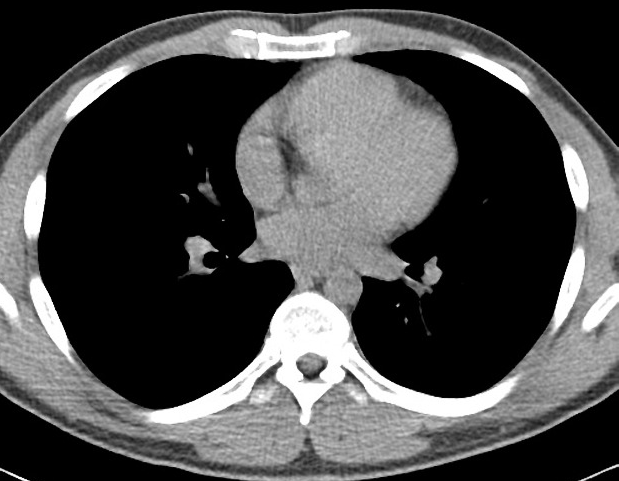

In [34]:
example = Image.open(train_files[1]).convert("RGB")
display(example)

In [35]:
img_size = 384
transforms = {
    "train": T.Compose([
        T.Resize((img_size, img_size), interpolation=T.InterpolationMode.BICUBIC),
        # T.RandomRotation(5, fill=255), #fill = 255 เติม background เป็นสีขาว
        T.ToTensor(),
        # T.Normalize(mean=torch.tensor([0.4850, 0.4560, 0.4060]), std=torch.tensor([0.2290, 0.2240, 0.2250]))
    ]),
    "test": T.Compose([
        T.Resize((img_size, img_size), interpolation=T.InterpolationMode.BICUBIC),
        T.ToTensor(),
        # T.Normalize(mean=torch.tensor([0.4850, 0.4560, 0.4060]), std=torch.tensor([0.2290, 0.2240, 0.2250]))
    ])
}

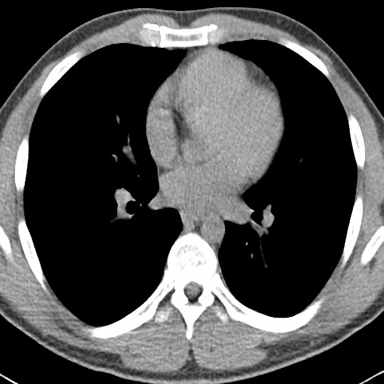

In [36]:
toImage = T.ToPILImage()
toImage(transforms["train"](example))

In [37]:
dataset = ImageDataset("./Data/train", transform=transforms["train"])
id2label = natsorted(os.listdir('./Data/train'))

In [38]:
id2label

['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa',
 'normal',
 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']

In [39]:
check = glob('./Data/train/**/**')
len(check)

679

In [40]:
y = glob('./Data/train/**/**')
y = natsorted(y)
y = [os.path.basename(os.path.dirname(i)) for i in y]

len(id2label), len(y) #len class, len sample

(4, 679)

In [41]:
len(dataset) #all image

747

### Train

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model_name = 'convnext_base.clip_laion2b_augreg_ft_in12k_in1k_384'
model_name = "maxvit_base_tf_384.in1k"
# model_name = "hf_hub:timm/maxvit_base_tf_224.in1k"

num_epochs = 20
criterion = nn.CrossEntropyLoss()

# Gradient Accumulation Settings
# Set to 1 for no accumulation
train_batch_size = 4
eval_batch_size = 4
num_accumulate = 4
num_classes = len(id2label)

# Cross Validation Configuration
k_splits = 10
metric = evaluate.load("f1")

In [43]:
all_eval_scores = []
!rm -rf croos_model
!mkdir croos_model

skf = StratifiedKFold(n_splits=k_splits, shuffle=True, random_state=42)
kf = KFold(n_splits=k_splits, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(dataset, y)):
# for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):

    print(f"\nFold {fold+1} of 10")

    # Load Model
    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes).to(device)

    # Load Optimizer and Scheduler
    optimizer = timm.optim.create_optimizer_v2(model, opt="AdamW", lr=1e-3)
    # optimizer = timm.optim.Lookahead(optimizer, alpha=0.5, k=6)                           # update the slow weight every k steps
                                                                                          # update the optimizer by combine slow weight and fast weight * alpha

    scheduler = timm.scheduler.create_scheduler_v2(optimizer, num_epochs=num_epochs)[0]

    # Load Data: split train and valition set based on kfold
    train_dataset = torch.utils.data.Subset(dataset, train_idx)
    val_dataset = torch.utils.data.Subset(dataset, val_idx)

    train_dataloader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=eval_batch_size, shuffle=False)

    # Reset Model Info
    info = {
        "metric_train": ['com'],
        "metric_val": ['com'],
        "train_loss": ['com'],
        "val_loss": ['com'],
        "best_metric_val": -999,
    }

    count = 0

    for epoch in range(num_epochs):
        train_loss_epoch = []
        val_loss_epoch = []

        train_preds = []
        train_targets = []

        val_preds = []
        val_targets = []

        num_updates = epoch * len(train_dataloader)

        ### === Train Loop === ###

        model.train()
        for idx, batch in enumerate(tqdm(train_dataloader)):
            inputs, targets = batch
            outputs = model(inputs.to(device))
            loss = criterion(outputs, targets.to(device))

            loss.backward()

            # === Gradient Accumulation === #
            if ((idx + 1) % num_accumulate == 0) or (idx + 1 == len(train_dataloader)):
                optimizer.step()
                scheduler.step_update(num_updates=num_updates)
                optimizer.zero_grad()
            # ============================= #

            train_loss_epoch.append(loss.item())
            train_preds += outputs.argmax(-1).detach().cpu().tolist()
            train_targets += targets.tolist()
        ### ==================== ###

        # optimizer.sync_lookahead()              # Sync slow weight and fast weight for lookahead
        optimizer.step()
        scheduler.step(epoch + 1)

        ### === Evaluation Loop === ###
        model.eval()
        with torch.no_grad():
            for batch in tqdm(val_dataloader):
                inputs, targets = batch
                outputs = model(inputs.to(device))
                loss = criterion(outputs, targets.to(device))

                # Log Values
                val_loss_epoch.append(loss.item())
                val_preds += outputs.argmax(-1).detach().cpu().tolist()
                val_targets += targets.tolist()
        ### ======================= ###

        # Log Data
        metric_train = metric.compute(predictions=train_preds, references=train_targets, average="macro")["f1"]
        metric_val = metric.compute(predictions=val_preds, references=val_targets, average="macro")["f1"]

        info["metric_train"][0] = metric_train
        info["metric_val"][0] = metric_val

        info["train_loss"][0] = np.average(train_loss_epoch)
        info["val_loss"][0] = np.average(val_loss_epoch)

        if metric_val > info["best_metric_val"]:
            print("\nNew Best Score!")
            info["best_metric_val"] = metric_val
            torch.save(model, f"croos_model/checkpoint_fold{fold}.pt")
            count = 0

        else:
            count += 1

        print(info)
        print(f"Fold: {fold} | Epoch: {epoch} | Metric: {metric_val} | Training Loss: {np.average(train_loss_epoch)} | Validation Loss: {np.average(val_loss_epoch)}\n")

#         #early stop
#         if count == 5:
#             besttt = info["best_metric_val"]
#             print(f'early score {besttt}')
#             break

    # save all best metric val
    all_eval_scores.append(info["best_metric_val"])

ValueError: ignored

### Predict

In [ ]:
all_eval_scores

[0.9270895770895771,
 0.9606060606060606,
 0.98380355276907,
 0.9868686868686869,
 0.9293650793650794,
 0.9104269293924466,
 0.9687531460787275,
 0.9819354838709677,
 0.9168312832627349,
 0.9718987908643081]

In [ ]:
id2label = natsorted(os.listdir('./Data/train'))
id2label = [i.split('_')[0] for i in id2label]
id2label

['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']

In [ ]:
#test data and y_true
test_files = natsorted(glob('./Data/test/**/**'))
y_true = [os.path.basename(os.path.dirname(i)) for i in test_files]

In [ ]:
#for ensemble method
pred_all = []

for fold in trange(k_splits):

    #load model
    model = torch.load(f"./croos_model/checkpoint_fold{fold}.pt")
    model.eval()

    pred = []
    with torch.no_grad():
        for f in tqdm(test_files):

            #image
            img = Image.open(f).convert("RGB")
            transformed = transforms["test"](img).unsqueeze(0).to(device)

            #cls
            cls = model(transformed).argmax(-1).item()
            cls = id2label[cls]

            pred.append(cls)

    #for ensemble method
    pred_all.append(pred)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/315 [00:00<?, ?it/s]

  0%|          | 0/315 [00:00<?, ?it/s]

  0%|          | 0/315 [00:00<?, ?it/s]

  0%|          | 0/315 [00:00<?, ?it/s]

...

  0%|          | 0/315 [00:00<?, ?it/s]

  0%|          | 0/315 [00:00<?, ?it/s]

  0%|          | 0/315 [00:00<?, ?it/s]

  0%|          | 0/315 [00:00<?, ?it/s]

  0%|          | 0/315 [00:00<?, ?it/s]

### Ensemble

In [ ]:
#ensemble_value
sub_ensemble = []

#num of fold
kfold = 10 #kfold

#ensemble
for i in trange(len(pred_all[0])):
    check = []

    #loop every fold
    for j in range(kfold):
        check.append(pred_all[j][i])

    #find mode of 10 answers
    cls = stats.mode(check)[0][0]
    sub_ensemble.append(cls)

  0%|          | 0/315 [00:00<?, ?it/s]

In [ ]:
acc = accuracy_score(y_true, sub_ensemble)
print(f'accuracy {acc}')

accuracy 0.9333333333333333


## Ensemble Weight Method

In [ ]:
all_eval_scores

[0.9270895770895771,
 0.9606060606060606,
 0.98380355276907,
 0.9868686868686869,
 0.9293650793650794,
 0.9104269293924466,
 0.9687531460787275,
 0.9819354838709677,
 0.9168312832627349,
 0.9718987908643081]

In [ ]:
lis_model = []
for fold in trange(k_splits):

    #load model
    model = torch.load(f"./croos_model/checkpoint_fold{fold}.pt")
    model.eval()

    lis_model.append(model)

  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
pred_weight = []
with torch.no_grad():
    for f in tqdm(test_files):

        #image
        img = Image.open(f).convert("RGB")
        transformed = transforms["test"](img).unsqueeze(0).to(device)

        #model
        for idx, model in enumerate(lis_model[0:1]):

            cls = model(transformed) * all_eval_scores[idx]

        for idx, model in enumerate(lis_model[1:]):
            cls2 = model(transformed) * all_eval_scores[idx+1]
            cls += cls2

        cls = cls.argmax(-1).item()
        cls = id2label[cls]

        pred_weight.append(cls)

  0%|          | 0/315 [00:00<?, ?it/s]

In [ ]:
acc = accuracy_score(y_true, pred_weight)
print(f'accuracy {acc}')

accuracy 0.9396825396825397


## Ensemble Weight Method But normalize
normalize model proba to 0-1

In [ ]:
pred_weight = []
with torch.no_grad():
    for f in tqdm(test_files):

        #image
        img = Image.open(f).convert("RGB")
        transformed = transforms["test"](img).unsqueeze(0).to(device)

        #model
        for idx, model in enumerate(lis_model[0:1]):

            prob = all_eval_scores[idx]

            cls = model(transformed)
            cls = cls.tolist()[0]

            #normalize
            min_value = min(cls)
            max_value = max(cls)
            cls = [(x - min_value) / (max_value - min_value) for x in cls]

            cls = [i*prob for i in cls]

        for idx, model in enumerate(lis_model[1:]):

            prob = all_eval_scores[idx+1]

            cls2 = model(transformed)
            cls2 = cls2.tolist()[0]

            #normalize
            min_value = min(cls2)
            max_value = max(cls2)
            cls2 = [(x - min_value) / (max_value - min_value) for x in cls2]

            cls2 = [i*prob for i in cls2]

            cls = [sum(x) for x in zip(cls, cls2)]

        cls = np.array(cls)
        cls = np.argmax(cls)
        cls = id2label[cls]

        pred_weight.append(cls)

  0%|          | 0/315 [00:00<?, ?it/s]

In [ ]:
acc = accuracy_score(y_true, pred_weight)
print(f'accuracy {acc}')

accuracy 0.9365079365079365
